# Blue River mit RTC-Tools: Lokale Ausfuehrung (Windows)

## Lernziele

In diesem Notebook lernen Sie, wie Sie das **Blue River**-Beispiel aus `Inhalt/simple_reservoir` lokal auf Windows ausfuehren:

- OpenModelica installieren und fuer das Beispiel vorbereiten.
- Eine separate RTC-Backend-Umgebung (`venvRTC-Tools`) aufsetzen.
- Das ShortTerm-Szenario starten und Ergebnisse pruefen.
- Ergebnisse fuer `TroutLake_V`, `TroutLake_Q_out` und `RiverCity_Q` visualisieren.
- Optional: LongTerm-Szenario ausfuehren und vergleichen.


## Umgebung einrichten

**Wichtig:** Dieses Notebook folgt dem Stil der anderen Kursnotebooks, trennt aber bewusst die Laufumgebung:

- Das Notebook selbst laeuft in Ihrer normalen Kursumgebung (Conda/requirements).
- Das RTC-Modell wird in einer separaten Backend-Umgebung `venvRTC-Tools` ausgefuehrt.
- Die **Eingangsdaten** liegen in `Inhalt/Notebook_Daten/RTC_BlueRiver`.
- **Ausgaben** des Notebooks werden in `Inhalt/Notebook_Daten/RTC_BlueRiver/runtime_case/output` geschrieben.

Dieses Notebook ist fuer **lokale Windows-Rechner** ausgelegt.


In [1]:
import platform
if platform.system() != "Windows":
    print("Hinweis: Dieses Notebook ist fuer Windows ausgelegt. Einige Kommandos sind plattformspezifisch.")
else:
    print("Windows erkannt - Setup kann wie vorgesehen genutzt werden.")


Windows erkannt - Setup kann wie vorgesehen genutzt werden.


## OpenModelica installieren (Windows)

Bitte fuehren Sie diese Schritte **einmalig** auf Ihrem Rechner aus:

1. Installieren Sie OpenModelica (OMEdit) von https://openmodelica.org/.
2. Starten Sie OMEdit.
3. Gehen Sie zu **Tools > Options > Libraries**.
4. Deaktivieren Sie **Load latest Modelica version on startup**.
5. Fuegen Sie als Systembibliothek **Modelica 3.2.3+maint.om** hinzu.
6. Speichern Sie die Einstellungen und starten Sie OMEdit neu.

### Smoke-Check in OMEdit

- Oeffnen Sie die Datei `Inhalt/simple_reservoir/BlueRiver2/model/BlueRiver.mo`.
- Pruefen Sie, dass das Modell ohne Fehlermeldung geladen wird.
- Optional: Fuehren Sie in OMEdit "Check Model" aus.


In [2]:
import os
import shutil
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "Inhalt" / "simple_reservoir" / "BlueRiver2").exists():
            return p
    raise FileNotFoundError("Repository-Wurzel mit Inhalt/simple_reservoir/BlueRiver2 nicht gefunden.")

REPO_ROOT = find_repo_root(Path.cwd())
BLUERIVER_DIR = REPO_ROOT / "Inhalt" / "simple_reservoir" / "BlueRiver2"
DATA_ROOT = REPO_ROOT / "Inhalt" / "Notebook_Daten" / "RTC_BlueRiver"

SCENARIO_SHORT = DATA_ROOT / "ShortTerm" / "input"
SCENARIO_LONG = DATA_ROOT / "LongTerm" / "input"
DATA_MODEL = DATA_ROOT / "model"

CASE_DIR = DATA_ROOT / "runtime_case"
CASE_INPUT = CASE_DIR / "input"
CASE_MODEL = CASE_DIR / "model"
CASE_SRC = CASE_DIR / "src"
CASE_XSD = CASE_DIR / "xsd"
CASE_OUTPUT = CASE_DIR / "output"

VENV_DIR = REPO_ROOT / "venvRTC-Tools"
VENV_PY = VENV_DIR / "Scripts" / "python.exe"

print(f"Repo root:     {REPO_ROOT}")
print(f"BlueRiver:     {BLUERIVER_DIR}")
print(f"Data root:     {DATA_ROOT}")
print(f"Runtime case:  {CASE_DIR}")
print(f"RTC venv:      {VENV_DIR}")

omedit_candidates = [
    shutil.which("omedit"),
    r"C:\\Program Files\\OpenModelica1.25.0-64bit\\bin\\omedit.exe",
    r"C:\\Program Files\\OpenModelica1.24.4-64bit\\bin\\omedit.exe",
    r"C:\\Program Files\\OpenModelica1.24.0-64bit\\bin\\omedit.exe",
]
found_omedit = [p for p in omedit_candidates if p and Path(p).exists()]
if found_omedit:
    print("OMEdit gefunden:")
    for p in found_omedit:
        print(" -", p)
else:
    print("OMEdit nicht automatisch gefunden. Installieren/konfigurieren Sie OpenModelica bitte manuell.")


Repo root:     c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel
BlueRiver:     c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\simple_reservoir\BlueRiver2
Data root:     c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver
Runtime case:  c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver\runtime_case
RTC venv:      c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\venvRTC-Tools
OMEdit nicht automatisch gefunden. Installieren/konfigurieren Sie OpenModelica bitte manuell.


## RTC-Backend (`venvRTC-Tools`) erstellen und Pakete installieren

Diese Zelle erstellt (falls noetig) eine dedizierte Python-Umgebung und installiert:

- `rtc-tools`
- `rtc-tools-channel-flow`
- `rtc-tools-interface`

**Hinweis:** Der Download kann einige Minuten dauern.


In [3]:
import subprocess
import sys

if not VENV_PY.exists():
    print("Erstelle venvRTC-Tools...")
    subprocess.run([sys.executable, "-m", "venv", str(VENV_DIR)], check=True)
else:
    print("venvRTC-Tools existiert bereits.")

print("Installiere/aktualisiere RTC-Pakete...")
subprocess.run([str(VENV_PY), "-m", "pip", "install", "--upgrade", "pip"], check=True)
subprocess.run([str(VENV_PY), "-m", "pip", "install", "rtc-tools", "rtc-tools-channel-flow", "rtc-tools-interface"], check=True)

print("Installierte Versionen:")
subprocess.run([str(VENV_PY), "-m", "pip", "show", "rtc-tools", "rtc-tools-channel-flow", "rtc-tools-interface"], check=False)


venvRTC-Tools existiert bereits.
Installiere/aktualisiere RTC-Pakete...
Installierte Versionen:


CompletedProcess(args=['c:\\Users\\grego\\OneDrive - Universitaet Duisburg-Essen\\GitHub\\repos\\Wassermengenwirtschaft_und_Klimawandel\\venvRTC-Tools\\Scripts\\python.exe', '-m', 'pip', 'show', 'rtc-tools', 'rtc-tools-channel-flow', 'rtc-tools-interface'], returncode=0)

## Pre-Run Checks

Vor dem Lauf pruefen wir, ob alle benoetigten Dateien vorhanden sind.


In [4]:
required_blue = [
    BLUERIVER_DIR / "src" / "BlueRiver.py",
    BLUERIVER_DIR / "model" / "BlueRiver.mo",
    BLUERIVER_DIR / "xsd" / "rtcDataConfig.xsd",
    BLUERIVER_DIR / "xsd" / "rtcSharedTypes.xsd",
]

required_data = [
    DATA_MODEL / "reservoirs.csv",
    DATA_MODEL / "volumelevel.csv",
]

required_short = [
    SCENARIO_SHORT / "goal_table.csv",
    SCENARIO_SHORT / "plot_table.csv",
    SCENARIO_SHORT / "rtcDataConfig.xml",
    SCENARIO_SHORT / "rtcParameterConfig.xml",
    SCENARIO_SHORT / "timeseries_import.csv",
    SCENARIO_SHORT / "timeseries_import.xml",
]

missing = [p for p in (required_blue + required_data + required_short) if not p.exists()]
if missing:
    raise FileNotFoundError("Folgende Dateien fehlen:\n" + "\n".join(str(p) for p in missing))

if not VENV_PY.exists():
    raise FileNotFoundError(f"RTC-Backend nicht gefunden: {VENV_PY}")

print("Alle Pflichtdateien vorhanden.")
print("Backend-Python:", VENV_PY)


Alle Pflichtdateien vorhanden.
Backend-Python: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\venvRTC-Tools\Scripts\python.exe


## Runtime-Case vorbereiten

Wir erzeugen eine lauffaehige Case-Struktur in `Inhalt/Notebook_Daten/RTC_BlueRiver/runtime_case`.
Dadurch landen alle Ergebnisse automatisch im Notebook_Daten-Ordner.


In [5]:
import os
import shutil
import stat
import time

def _on_rm_error(func, path, exc_info):
    # Windows/OneDrive: read-only Attribute entfernen und erneut versuchen
    try:
        os.chmod(path, stat.S_IWRITE)
        func(path)
    except Exception:
        pass

def _remove_path(path: Path):
    if path.is_dir() and not path.is_symlink():
        shutil.rmtree(path, onerror=_on_rm_error)
    else:
        os.chmod(path, stat.S_IWRITE)
        path.unlink(missing_ok=True)

def _clear_dir(path: Path, retries: int = 5, delay_s: float = 0.4):
    # Root-Ordner behalten, nur Inhalt loeschen (robuster unter Windows)
    path.mkdir(parents=True, exist_ok=True)
    for child in list(path.iterdir()):
        for attempt in range(1, retries + 1):
            try:
                _remove_path(child)
                break
            except PermissionError:
                if attempt == retries:
                    raise
                time.sleep(delay_s * attempt)

def prepare_case(scenario_input: Path):
    # Frische Ordnerstruktur
    for p in [CASE_INPUT, CASE_MODEL, CASE_SRC, CASE_XSD, CASE_OUTPUT]:
        _clear_dir(p)

    # Code, Modell und XSD aus der Referenz kopieren
    shutil.copytree(BLUERIVER_DIR / "src", CASE_SRC, dirs_exist_ok=True)
    shutil.copytree(BLUERIVER_DIR / "model", CASE_MODEL, dirs_exist_ok=True)
    shutil.copytree(BLUERIVER_DIR / "xsd", CASE_XSD, dirs_exist_ok=True)

    # Modell-Input aus Notebook_Daten ueberlagern
    shutil.copy2(DATA_MODEL / "reservoirs.csv", CASE_MODEL / "reservoirs.csv")
    shutil.copy2(DATA_MODEL / "volumelevel.csv", CASE_MODEL / "volumelevel.csv")

    # Szenario-Input kopieren
    shutil.copytree(scenario_input, CASE_INPUT, dirs_exist_ok=True)

    print("Case vorbereitet:", CASE_DIR)
    print("Input:", CASE_INPUT)
    print("Output:", CASE_OUTPUT)


## ShortTerm-Szenario aktivieren (Standardpfad)

Wir nutzen das ShortTerm-Szenario aus:
`Inhalt/Notebook_Daten/RTC_BlueRiver/ShortTerm/input`


In [6]:
prepare_case(SCENARIO_SHORT)
print("ShortTerm-Szenario ist aktiv.")


Case vorbereitet: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver\runtime_case
Input: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver\runtime_case\input
Output: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver\runtime_case\output
ShortTerm-Szenario ist aktiv.


## BlueRiver ausfuehren (RTC-Backend)

Wir starten das Modell direkt ueber die dedizierte Backend-Umgebung.
Die Ausgabe wird in `runtime_case/venv-log.txt` geschrieben und in der Zelle angezeigt.


In [7]:
import os
import subprocess


run_cmd = [str(VENV_PY), "BlueRiver.py"]
run_cwd = CASE_SRC
print("Starte:", " ".join(run_cmd))

run_env = os.environ.copy()
run_env["MPLBACKEND"] = "Agg"
result = subprocess.run(run_cmd, cwd=run_cwd, env=run_env, capture_output=True, text=True)
combined_log = (result.stdout or "") + "\n" + (result.stderr or "")
log_path = CASE_DIR / "venv-log.txt"
log_path.write_text(combined_log, encoding="utf-8")

print("Return code:", result.returncode)
print("Log gespeichert in:", log_path)
print("\n--- Letzte Logzeilen ---")
print("\n".join(combined_log.splitlines()[-40:]))

if result.returncode != 0:
    raise RuntimeError("BlueRiver-Lauf fehlgeschlagen. Siehe venv-log.txt und Troubleshooting-Abschnitt.")


Starte: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\venvRTC-Tools\Scripts\python.exe BlueRiver.py
Return code: 0
Log gespeichert in: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver\runtime_case\venv-log.txt

--- Letzte Logzeilen ---
2026-03-04 15:31:00,231 INFO Done with optimize()
2026-03-04 15:31:00,231 INFO Extracting results
2026-03-04 15:31:00,233 INFO Done extracting results
2026-03-04 15:31:00,242 INFO Solving goals at priority 4
2026-03-04 15:31:00,242 INFO Entering optimize()
2026-03-04 15:31:00,242 INFO Transcribing problem with a DAE of 3 equations, 57 collocation points, and 6 free variables
CasADi - 2026-03-04 15:31:00 WARNING("CasADi was not compiled with WITH_OPENMP=ON. Falling back to serial evaluation.") [.../casadi/core/map.cpp:406]
2026-03-04 15:31:00,245 INFO Transcribing ensemble member 1/1
2026-03-04 15:31:00,2

## Ergebnisdateien validieren

Wir pruefen, ob die Exportdateien geschrieben wurden und ob die Kerndaten vorhanden sind.


In [8]:
import xml.etree.ElementTree as ET
import pandas as pd

out_csv = CASE_OUTPUT / "timeseries_export.csv"
out_diag = CASE_OUTPUT / "diag.xml"
perf_dir = CASE_OUTPUT / "performance_metrics"
run_log = CASE_DIR / "venv-log.txt"

if not out_csv.exists():
    raise FileNotFoundError(f"Fehlt: {out_csv}")

df = pd.read_csv(out_csv, parse_dates=["time"])
required_cols = ["time", "TroutLake_V", "TroutLake_Q_out", "RiverCity_Q"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError("Fehlende Spalten in timeseries_export.csv: " + ", ".join(missing_cols))
if df.empty:
    raise ValueError("timeseries_export.csv ist leer.")

diag_info = "Keine Diag-Information gefunden."
if out_diag.exists():
    root = ET.parse(out_diag).getroot()
    lines = list(root)
    levels = {"1": 0, "2": 0, "3": 0}
    for line in lines:
        lvl = line.attrib.get("level")
        if lvl in levels:
            levels[lvl] += 1
    diag_info = f"diag.xml vorhanden. Level-Count: {levels}"
elif perf_dir.exists() and list(perf_dir.glob("*.csv")):
    diag_info = f"diag.xml fehlt, aber performance_metrics vorhanden ({len(list(perf_dir.glob('*.csv')))} Dateien)."
elif run_log.exists():
    log_text = run_log.read_text(encoding="utf-8", errors="ignore")
    if "Traceback" in log_text:
        raise RuntimeError("venv-log.txt enthaelt einen Traceback. Lauf pruefen.")
    if "Done goal programming" in log_text:
        diag_info = "diag.xml fehlt, aber Lauf laut venv-log.txt erfolgreich (Done goal programming)."
    else:
        raise FileNotFoundError("Weder diag.xml noch performance_metrics gefunden. Laufpruefung unvollstaendig.")
else:
    raise FileNotFoundError("Weder diag.xml noch performance_metrics/venv-log.txt gefunden.")

print("CSV ok. Zeilen:", len(df))
print(diag_info)
short_term_df = df.copy()


CSV ok. Zeilen: 57
diag.xml fehlt, aber performance_metrics vorhanden (4 Dateien).


## Ergebnisse plotten (ShortTerm)

Visualisierung der drei Kernvariablen:

- `TroutLake_V`
- `TroutLake_Q_out`
- `RiverCity_Q`


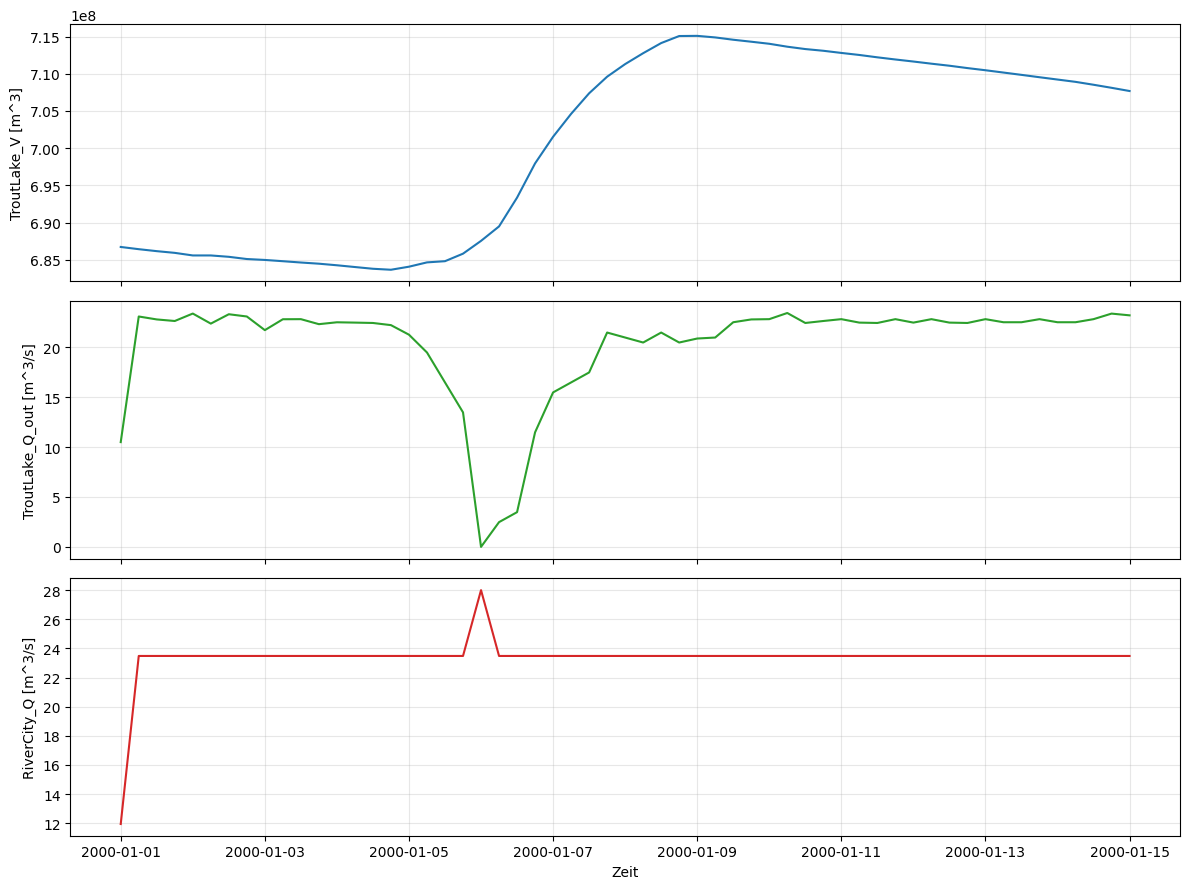

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(short_term_df["time"], short_term_df["TroutLake_V"], color="tab:blue")
axes[0].set_ylabel("TroutLake_V [m^3]")
axes[0].grid(True, alpha=0.3)

axes[1].plot(short_term_df["time"], short_term_df["TroutLake_Q_out"], color="tab:green")
axes[1].set_ylabel("TroutLake_Q_out [m^3/s]")
axes[1].grid(True, alpha=0.3)

axes[2].plot(short_term_df["time"], short_term_df["RiverCity_Q"], color="tab:red")
axes[2].set_ylabel("RiverCity_Q [m^3/s]")
axes[2].set_xlabel("Zeit")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Optional: LongTerm-Szenario

Diese Erweiterung ist optional. Setzen Sie in der naechsten Zelle `RUN_LONGTERM = True`,
um LongTerm zu aktivieren, erneut zu rechnen und mit ShortTerm zu vergleichen.


Case vorbereitet: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver\runtime_case
Input: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver\runtime_case\input
Output: c:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebook_Daten\RTC_BlueRiver\runtime_case\output
LongTerm-Zeilen: 61


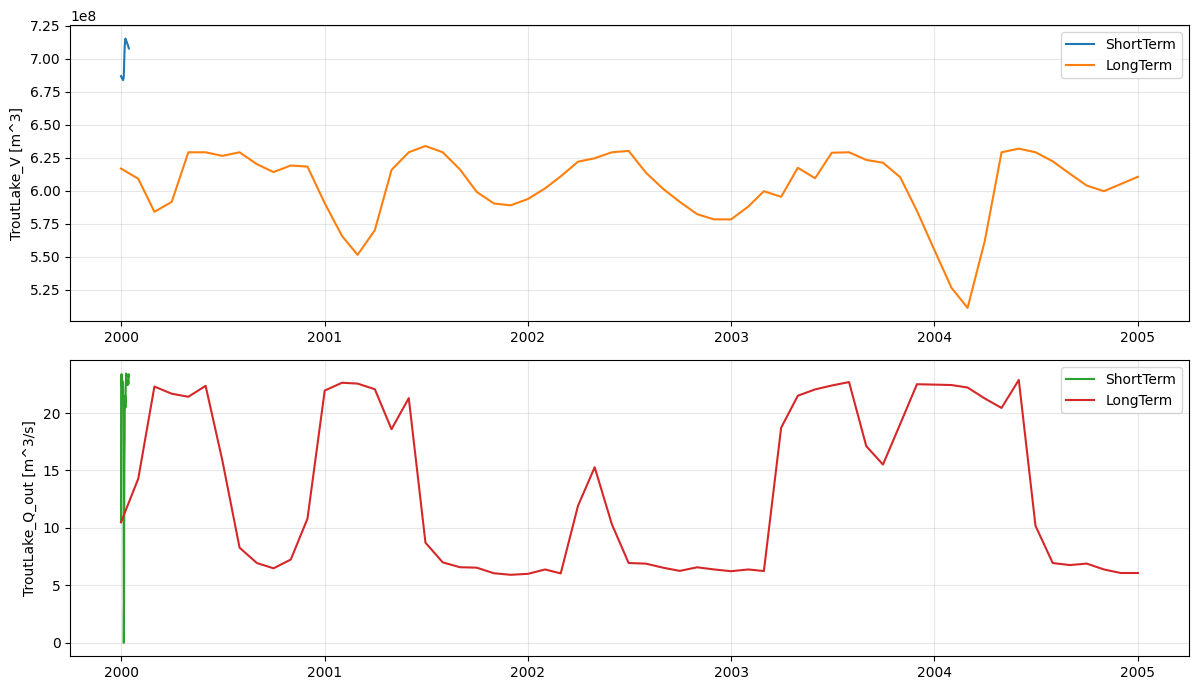

In [11]:
RUN_LONGTERM = True

if not RUN_LONGTERM:
    print("LongTerm uebersprungen. Setzen Sie RUN_LONGTERM=True fuer die Erweiterung.")
else:
    prepare_case(SCENARIO_LONG)

    run_env_long = os.environ.copy()
    run_env_long["MPLBACKEND"] = "Agg"
    result_long = subprocess.run([str(VENV_PY), "BlueRiver.py"], cwd=CASE_SRC, env=run_env_long, capture_output=True, text=True)
    combined_long = (result_long.stdout or "") + "\n" + (result_long.stderr or "")
    (CASE_DIR / "venv-log.txt").write_text(combined_long, encoding="utf-8")
    if result_long.returncode != 0:
        raise RuntimeError("LongTerm-Lauf fehlgeschlagen. Siehe venv-log.txt")

    long_df = pd.read_csv(CASE_OUTPUT / "timeseries_export.csv", parse_dates=["time"])
    print("LongTerm-Zeilen:", len(long_df))

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
    axes[0].plot(short_term_df["time"], short_term_df["TroutLake_V"], label="ShortTerm", color="tab:blue")
    axes[0].plot(long_df["time"], long_df["TroutLake_V"], label="LongTerm", color="tab:orange")
    axes[0].set_ylabel("TroutLake_V [m^3]")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(short_term_df["time"], short_term_df["TroutLake_Q_out"], label="ShortTerm", color="tab:green")
    axes[1].plot(long_df["time"], long_df["TroutLake_Q_out"], label="LongTerm", color="tab:red")
    axes[1].set_ylabel("TroutLake_Q_out [m^3/s]")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Troubleshooting

1. **`ModuleNotFoundError` fuer RTC-Pakete**
   - Setup-Zelle fuer `venvRTC-Tools` erneut ausfuehren.
   - Pruefen, ob `VENV_PY` auf `...\\venvRTC-Tools\\Scripts\\python.exe` zeigt.

2. **OpenModelica wird nicht gefunden**
   - OpenModelica installieren und OMEdit starten.
   - Optional den Installationspfad von OMEdit zur Windows-PATH-Variable hinzufuegen.

3. **Pfadprobleme (z. B. OneDrive, Leerzeichen)**
   - Notebook immer aus dem Repository-Kontext starten.
   - Keine relativen Pfade manuell aendern; die Zellen verwenden `REPO_ROOT` und `DATA_ROOT`.

4. **Warnungen/Fehler in Diagnoseausgaben**
   - Primaer `Inhalt/Notebook_Daten/RTC_BlueRiver/runtime_case/venv-log.txt` pruefen.
   - Falls vorhanden, `output/diag.xml` auswerten (Level 1 = Fehler).
   - Alternativ `output/performance_metrics/*.csv` als Laufnachweis nutzen.
   - Bei Infeasibility zuerst Szenario-Input und Goal-Tabellen pruefen.
